# IM3 Data Center Atlas: Data Preprocessing and analysis

### Environment setup & dependencies
- Importing the necessary libraries for data processing (Pandas, NumPy) and geospatial visualization (Matplotlib, GeoPandas)

In [99]:
from zipfile import Path
import pandas as pd 
from pathlib import Path

import matplotlib.pyplot as plt 
import numpy as np 
import geopandas as gpd 


### Raw data ingestion & structural inspection
- Loading the raw IM3 Open Source Data Center Atlas CSV file into a Pandas dataframe, before cleaning. Inspecting first and last few rows

In [100]:
df = pd.read_csv("Data/im3_atlas.csv")
df
df.head()
df.tail()


,id,state,state_abb,state_id,county,county_id,operator,ref,name,sqft,lon,lat,type
1237,12387534800,New Mexico,NM,35,Bernalillo County,1,UNM,UNM,UNM Data Center,NaN,-106.615348,35.086739,point
1238,12437277166,California,CA,6,Santa Clara County,85,Prime,NaN,Prime Santa Clara,NaN,-121.962865,37.366662,point
1239,12452254071,New Jersey,NJ,34,Middlesex County,23,NaN,NaN,Open Data Centers Piscataway,NaN,-74.456856,40.550350,point
1240,12471740457,New Jersey,NJ,34,Hudson County,17,H5,NaN,H5 Secaucus,NaN,-74.075012,40.785395,point
1241,12550746951,California,CA,6,Santa Clara County,85,NaN,NaN,"Forescout Technologies, Inc.",NaN,-121.947418,37.322868,point


### Data structure & value inspection
- Checking dataframe info, column data types, missing value totals per column, duplicate counts, and summary statistics

In [101]:
df.info()
#458 nulls in operator col
#915 nulls in ref col
#213 nulls in name
#93 nulls in sqft

df.duplicated().sum()
df.nunique()
df.describe
df.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 1242 entries, 0 to 1241
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         1242 non-null   int64  
 1   state      1242 non-null   str    
 2   state_abb  1242 non-null   str    
 3   state_id   1242 non-null   int64  
 4   county     1242 non-null   str    
 5   county_id  1242 non-null   int64  
 6   operator   784 non-null    str    
 7   ref        327 non-null    str    
 8   name       1029 non-null   str    
 9   sqft       1149 non-null   float64
 10  lon        1242 non-null   float64
 11  lat        1242 non-null   float64
 12  type       1242 non-null   str    
dtypes: float64(3), int64(3), str(7)
memory usage: 126.3 KB


id             0
state          0
state_abb      0
state_id       0
county         0
county_id      0
operator     458
ref          915
name         213
sqft          93
lon            0
lat            0
type           0
dtype: int64

### Deduplication & missing value cleanup
- Deduplicating records by unique facility id to handle facilities that straddle county lines, resetting the index, dropping the ref column and rows missing sqft, and filling missing operator & name fields with 'Unknown'

In [102]:
df = df.drop_duplicates() 
df = df.drop_duplicates(subset=['id']).reset_index(drop=True) 

df['operator'] = df['operator'].fillna('Unknown') 
df['ref'] = df['ref'].fillna('Unknown') 
df['name'] = df['name'].fillna('Unknown') 
df.loc[df['type'].isin(['building', 'campus']) & (df['sqft'].isnull()), 'sqft'] 


Series([], Name: sqft, dtype: float64)

### Data type formatting and string whitespace cleanup
- Casting ID parameter to explicity integers, stripping leading/trailing whitespace from string fields, and converting coordinates (lat & lon) and facility area (sqft) to float data types

In [103]:
df['id'] = df['id'].astype(int)
df['state_id'] = df['state_id'].astype(int)
df['county_id'] = df['county_id'].astype(int)

string_cols = ['state', 'state_abb', 'county', 'operator', 'ref', 'name', 'type']
for col in string_cols:
    df[col] = df[col].astype(str).str.strip()

df['sqft'] = df['sqft'].astype(float)
df['lat'] = df['lat'].astype(float)
df['lon'] = df['lon'].astype(float)

### Area and coordinate bounding
- Bounding latitude and longitude coordinates and filtering positive square footage
- Categorizing facility size (sqft) into a numeric 'size_class' column: 0 = Small (<20,000 sqft, combining micro & small), 1 = medium (20,000–100,000 sqft), and 2 = hyperscale (100,000+ sqft)
- Filtering the dataframe to retain only the core required columns

In [104]:
df = df[df['sqft'] > 0]
df = df[(df['lat'].between(17.0, 72.0)) & (df['lon'].between(-170.0, -65.0))]

sqft_bins = [0,20000, 100000, np.inf]
sqft_labels = [0,1,2]

df['size_class'] = pd.cut(
    df['sqft'],
    bins=sqft_bins,
    labels=sqft_labels,
    right=False
).astype(int)

keep_cols = ['id', 'sqft','lat','lon','type','size_class']
df=df[keep_cols]

df.head()


df['size_class'].value_counts().sort_index()


size_class
0    111
1    330
2    706
Name: count, dtype: int64

### Cleaned data verification
- Rechecking missing value counts and duplicate rows after cleaning to verify the dataframe structure

In [105]:
print("Remaining Missing Values:/n", df.isnull().sum()) 
print("Remaining Duplicates:/n", df.duplicated().sum()) 
df.info

Remaining Missing Values:/n id            0
sqft          0
lat           0
lon           0
type          0
size_class    0
dtype: int64
Remaining Duplicates:/n 0


<bound method DataFrame.info of               id        sqft        lat         lon      type  size_class
0        2744301    105786.0  40.544256  -74.496521  building           2
1        7805491    188209.0  40.100657  -82.814358  building           2
2        9474864   3407194.0  35.894738  -81.546515    campus           2
3       13924557  10962475.0  41.515955  -93.711719    campus           2
4       14593270   5431080.0  35.588771  -81.261809    campus           2
...          ...         ...        ...         ...       ...         ...
1142  1226436457    382799.0  41.212214  -95.878019    campus           2
1143  1317915930    287687.0  39.021948  -77.453194    campus           2
1144  1339825480  21448981.0  41.342576  -96.091326    campus           2
1145  1356594646   3405106.0  33.353834 -111.612394    campus           2
1146  1357825755   1290579.0  33.454488 -111.976455    campus           2

[1147 rows x 6 columns]>

### Export cleaned checkpoint
- Saving the processed datframe to 'im3_atlas_cleaned.csv' as a clean data checkpoint

In [106]:
df.to_csv("Data/im3_atlas_cleaned.csv", index=False) 
df.shape

(1147, 6)

### Loading cleaned checkpoint
- Reading 'im3_atlas_cleaned.csv' back into Pandas to verify that all 13 columns are loaded properly before generating plots 

In [107]:
data = pd.read_csv("Data/im3_atlas_cleaned.csv") 
data.info()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 1147 entries, 0 to 1146
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          1147 non-null   int64  
 1   sqft        1147 non-null   float64
 2   lat         1147 non-null   float64
 3   lon         1147 non-null   float64
 4   type        1147 non-null   str    
 5   size_class  1147 non-null   int64  
dtypes: float64(3), int64(2), str(1)
memory usage: 53.9 KB


Index(['id', 'sqft', 'lat', 'lon', 'type', 'size_class'], dtype='str')

### Geocoordinate Hexbin density map
- Generating a hexagonal binning plot where the color of each bin represents the concentration density of data center facilities across coordinate clusters

<function matplotlib.pyplot.show(close=None, block=None)>

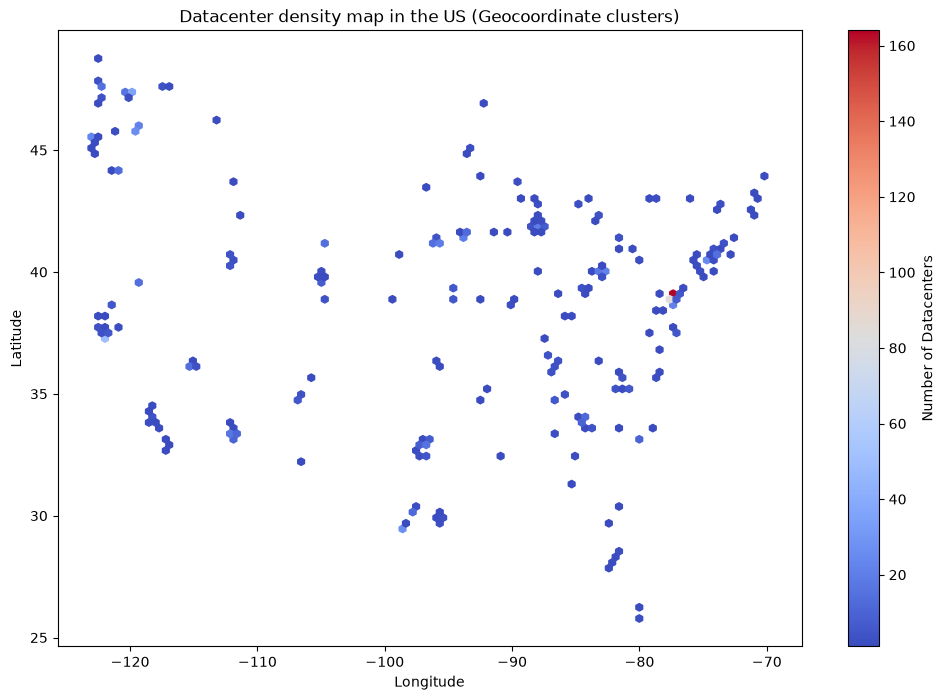

In [108]:
plt.figure(figsize=(12, 8))
hb = plt.hexbin(data['lon'], data['lat'], gridsize=(100,50), cmap='coolwarm',mincnt=1) 
cb = plt.colorbar(hb,label = 'Number of Datacenters') 

plt.title('Datacenter density map in the US (Geocoordinate clusters)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show


### GeoPandas World Map spatial overlay
- Covering long and lat coordinates into a Geodataframe using the WGS84 (EPSG:4326) coordinate reference system and overlaying facility locations onto a base map

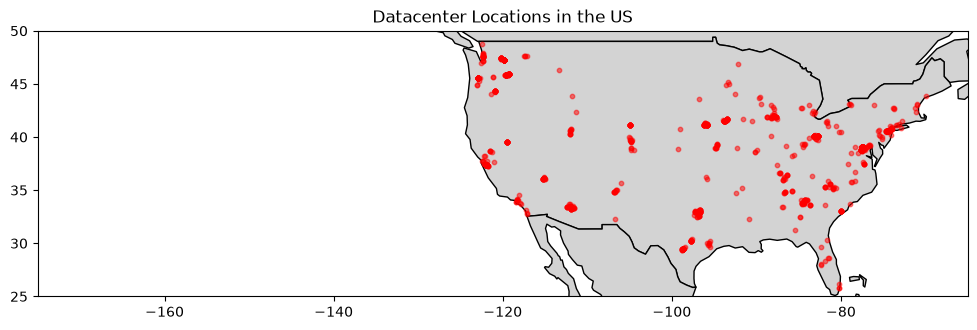

In [109]:
gdf = gpd.GeoDataFrame(data, geometry=gpd.points_from_xy(data['lon'], data['lat'])) # converting the pandas dataframe to a geopandas dataframe by creating a geometry column from the lat and lon columns
gdf.set_crs(epsg=4326, inplace=True) 
world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip") # loading the world map from geopandas datasets
ax = world.plot(figsize=(12, 8), color='lightgrey', edgecolor='black') # plotting the world map

ax.set_xlim([-175, -65]) 
ax.set_ylim([25, 50]) 

gdf.plot(ax=ax, markersize=10, color='red', alpha=0.5) 
plt.title('Datacenter Locations in the US') 
plt.show()


### State facility rankings bar chart
- Ranking states by total facility count using 'value_counts()' and plotting the distribution as a bar chart

In [112]:
plt.figure(figsize=(12,6))
state_counts = data['state'].value_counts().sort_values(ascending=False)
state_counts.plot(kind='bar', color = 'darkblue')
plt.title('Number of Datacenter Facilities per State')
plt.xlabel('State')
plt.ylabel('Number of Facilities')
plt.show()


KeyError: 'state'

<Figure size 1200x600 with 0 Axes>

### Facility size threshold distribution
- States are ranked by total facility count and then the distribution among top 5 states are analyzed visually, by binning sqft into 5 size thresholds. Below is how it is sorted:
   - micro: under 5,000 sqft
   - small: 5,000-20,000 sqft
   - medium: 20,000-100,000 sqft
   - large: 100,000-500,000 sqft
   - hyperscale: 500,000+ sqft

Top 5 states: ['Virginia', 'Oregon', 'Texas', 'California', 'Washington']


<Figure size 1400x600 with 0 Axes>

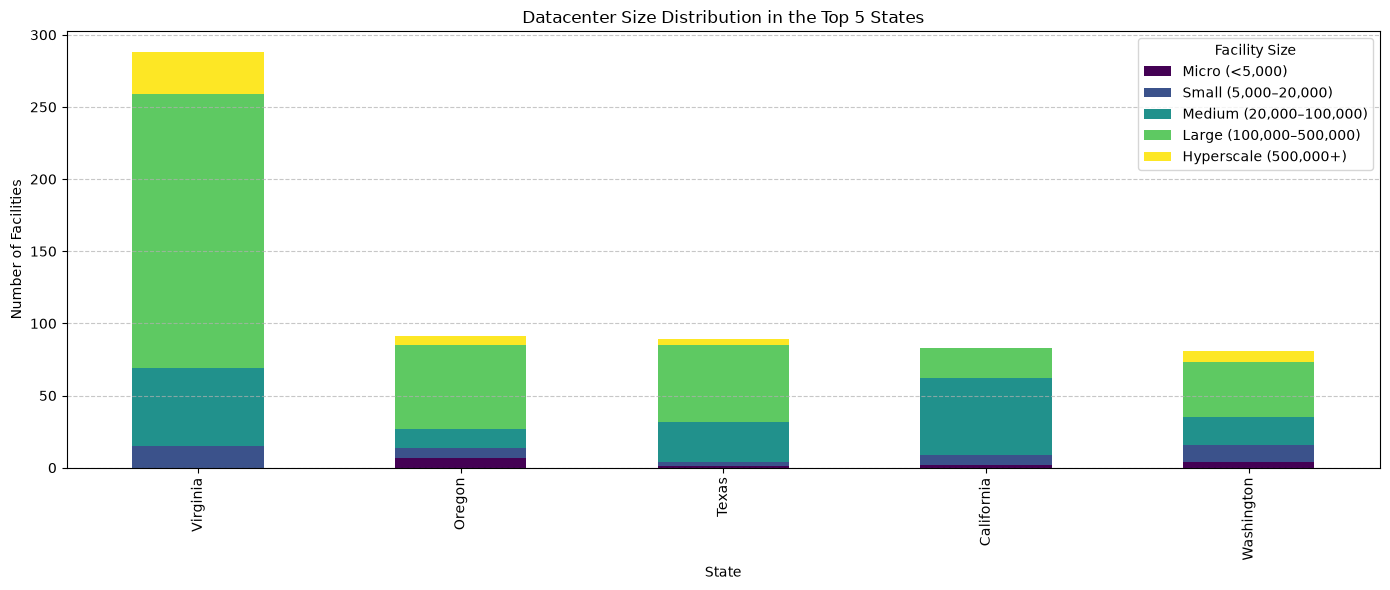

In [ ]:

top_5_states = data['state'].value_counts().head(5).index.tolist()
print('Top 5 states:', top_5_states)

#sqft bins and size category labels
sqft_bins = [0, 5000, 20000, 100000, 500000, np.inf]
sqft_labels = [
    'Micro (<5,000)',
    'Small (5,000–20,000)',
    'Medium (20,000–100,000)',
    'Large (100,000–500,000)',
    'Hyperscale (500,000+)'
]

#facility sizes into a new column
data['sqft_category'] = pd.cut(
    data['sqft'],
    bins=sqft_bins,
    labels=sqft_labels,
    right=False
)

#filter
df_top5=data[data['state'].isin(top_5_states)]

#cross tabulation table: state vs sqft_category
size_distribution = pd.crosstab(df_top5['state'], df_top5['sqft_category'])

plt.figure(figsize=(14, 6))
# sort states by total facility count so the bars appear in descending order
size_distribution = size_distribution.loc[
    size_distribution.sum(axis=1).sort_values(ascending=False).index
]

ax = size_distribution.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 6),
    colormap='viridis'
)
plt.title('Datacenter Size Distribution in the Top 5 States')
plt.xlabel('State')
plt.ylabel('Number of Facilities')
plt.legend(title='Facility Size')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()  